In [1]:
import tensorflow as tf
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import time

# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)



In [2]:

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0


C:\Users\kadia\AppData\Roaming\Python\Python313\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [3]:
num_classes = 10
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes)
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes)


class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']



In [4]:
x_train.shape

(50000, 32, 32, 3)

In [5]:
x_test.shape

(10000, 32, 32, 3)

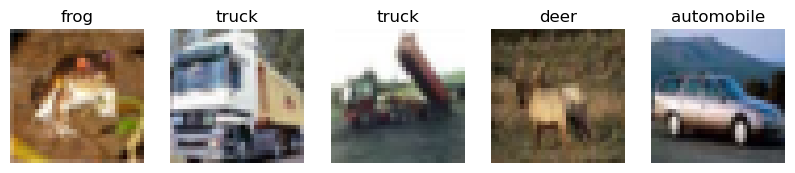

In [6]:
# visualize data
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.show()

In [7]:

ann_model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(32, 32, 3)),

    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
], name="ANN_Model")



C:\Users\kadia\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
# Compile the model
ann_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

In [9]:
ann_model.summary()

Model: "ANN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Training ANN
ann_history = ann_model.fit(x_train, y_train_cat,
                            epochs=15,
                            batch_size=64,
                            validation_data=(x_test, y_test_cat),
                            verbose=1)

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.2712 - loss: 1.9797 - val_accuracy: 0.3444 - val_loss: 1.8238
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.3271 - loss: 1.8403 - val_accuracy: 0.3825 - val_loss: 1.7229
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.3544 - loss: 1.7774 - val_accuracy: 0.4046 - val_loss: 1.6946
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.3680 - loss: 1.7411 - val_accuracy: 0.4028 - val_loss: 1.6660
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.3786 - loss: 1.7129 - val_accuracy: 0.4182 - val_loss: 1.6504
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.3863 - loss: 1.6942 - val_accuracy: 0.4346 - val_loss: 1.5990
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.3924 - loss: 1.6780 - val_accuracy: 0.4393 - val_loss: 1.6065
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.3976 - loss: 1.6618 - val_accuracy:

In [11]:
# building CNN model
cnn_model = tf.keras.Sequential([
    
    tf.keras.layers.Conv2D(32, (5, 5), activation='relu', padding='same', input_shape=(32, 32, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.BatchNormalization(), 


    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    

    tf.keras.layers.Dense(10, activation='softmax')
], name="CNN_Model")




C:\Users\kadia\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
cnn_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

In [13]:
cnn_model.summary()

Model: "CNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 359,242 (1.37 MB)

 Trainable params: 358,794 (1.37 MB)

 Non-trainable params: 448 (1.75 KB)

In [14]:
# training CNN
cnn_history = cnn_model.fit(x_train, y_train_cat,
                            epochs=15,
                            batch_size=64,
                            validation_data=(x_test, y_test_cat),
                            verbose=1)

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.4961 - loss: 1.4245 - val_accuracy: 0.4927 - val_loss: 1.4304
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.6359 - loss: 1.0286 - val_accuracy: 0.5258 - val_loss: 1.5392
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.7016 - loss: 0.8507 - val_accuracy: 0.6557 - val_loss: 0.9852
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.7445 - loss: 0.7309 - val_accuracy: 0.6730 - val_loss: 0.9697
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.7801 - loss: 0.6267 - val_accuracy: 0.6857 - val_loss: 0.9580
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 25ms/step - accuracy: 0.8080 - loss: 0.5396 - val_accuracy: 0.6876 - val_loss: 0.9791
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.8360 - loss: 0.4648 - val_accuracy: 0.6822 - val_loss: 1.0782
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.8545 - loss: 0.4114 - 

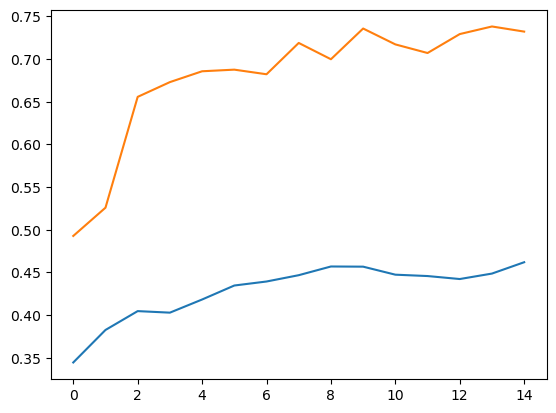

In [15]:
plt.plot(ann_history.history['val_accuracy'])
plt.plot(cnn_history.history['val_accuracy'])

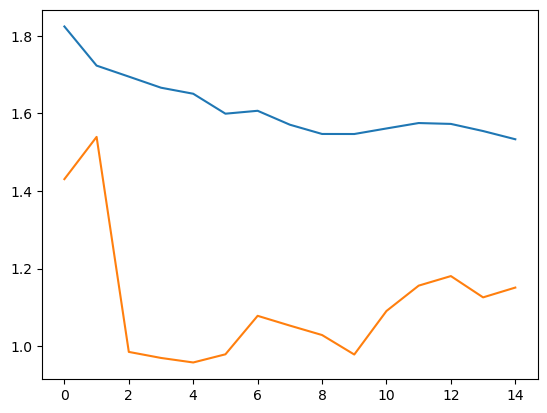

In [16]:
plt.plot(ann_history.history['val_loss'])
plt.plot(cnn_history.history['val_loss'])

In [17]:
# Get predictions
cnn_pred_probs = cnn_model.predict(x_test)
cnn_preds = np.argmax(cnn_pred_probs, axis=1)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


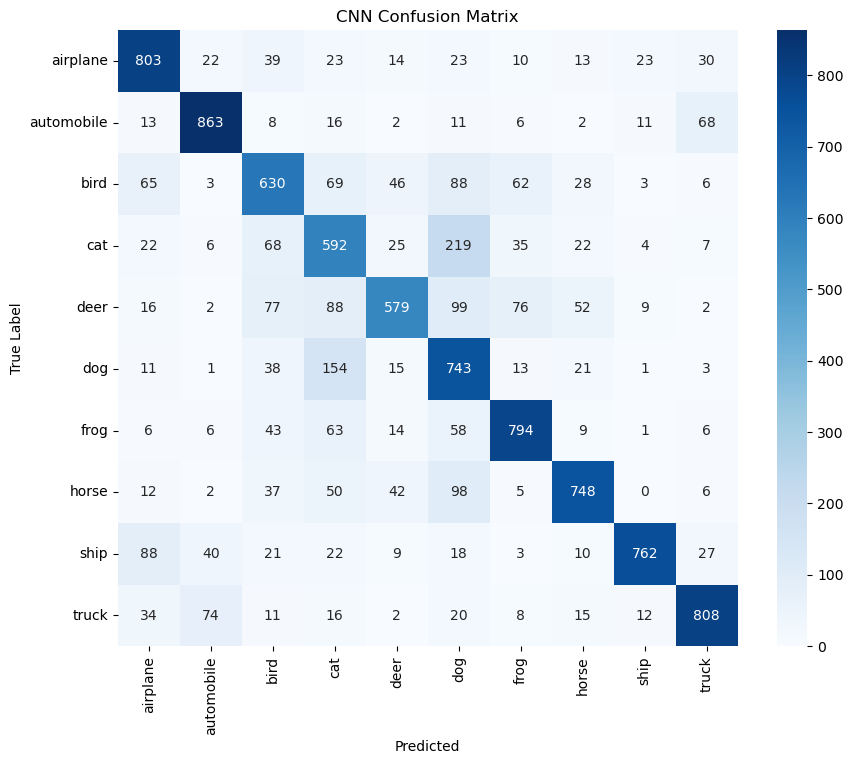

In [18]:
# 1. Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, cnn_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('CNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True Label')
plt.show()

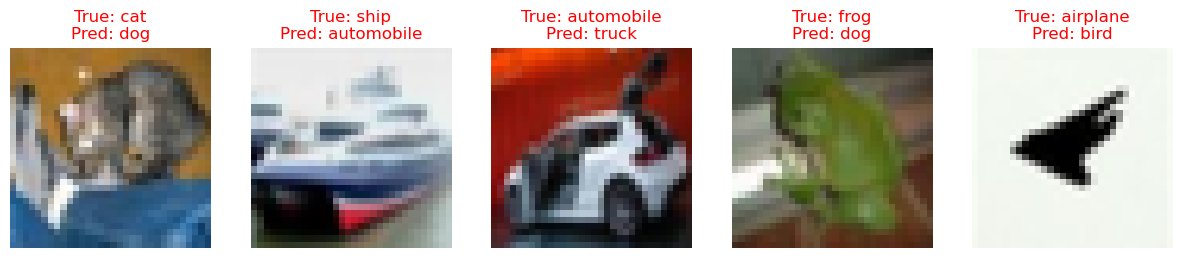

In [19]:
#  Visualize 5 Misclassified Samples
misclassified_indices = np.where(cnn_preds != y_test.flatten())[0]

plt.figure(figsize=(15, 3))
for i, idx in enumerate(misclassified_indices[:5]):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_test[idx])
    true_lbl = class_names[y_test[idx][0]]
    pred_lbl = class_names[cnn_preds[idx]]
    plt.title(f"True: {true_lbl}\nPred: {pred_lbl}", color='red')
    plt.axis('off')
plt.show()

In [20]:
# Evaluate final accuracy
ann_loss, ann_acc = ann_model.evaluate(x_test, y_test_cat, verbose=0)
cnn_loss, cnn_acc = cnn_model.evaluate(x_test, y_test_cat, verbose=0)

# Count parameters
ann_params = ann_model.count_params()
cnn_params = cnn_model.count_params()

print("\n--- FINAL COMPARATIVE SUMMARY ---")
print(f"{'Model':<10} | {'Test Accuracy':<15} | {'Training Time (s)':<20} | {'Parameters':<15}")
print("-" * 70)
print(f"{'ANN':<10} | {ann_acc*100:.2f}%                 | {ann_params:,}")
print(f"{'CNN':<10} | {cnn_acc*100:.2f}%                 | {cnn_params:,}")
print("-" * 70)

print("\nConclusion:")
print("1. CNN achieves higher accuracy because it captures spatial features (edges, textures) using Convolutional layers.")
print("2. ANN loses spatial information by flattening the image immediately, making it less effective for complex image data.")


--- FINAL COMPARATIVE SUMMARY ---
Model      | Test Accuracy   | Training Time (s)    | Parameters     
----------------------------------------------------------------------
ANN        | 46.19%                 | 1,738,890
CNN        | 73.22%                 | 359,242
----------------------------------------------------------------------

Conclusion:
1. CNN achieves higher accuracy because it captures spatial features (edges, textures) using Convolutional layers.
2. ANN loses spatial information by flattening the image immediately, making it less effective for complex image data.
